In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import io
import seaborn
seaborn.set()

In [2]:
from google.colab import files
uploaded = files.upload()

Saving costs.csv to costs.csv
Saving profiles.csv to profiles.csv
Saving verification.csv to verification.csv


In [3]:
# Loading the files
verification_df = pd.read_csv(io.BytesIO(uploaded['verification.csv']))
profiles_df = pd.read_csv(io.BytesIO(uploaded['profiles.csv']))
costs_df = pd.read_csv(io.BytesIO(uploaded['costs.csv']))


In [4]:

# Quick view into the 3 DF
print("Verification Data:")
display(verification_df.head())

print("Profiles Data:")
display(profiles_df.head())

print("Costs Data:")
display(costs_df.head())

Verification Data:


,userID,group,method,verified
0,mpr_2fHOBr0Nw6mNM2fPIKMeSyKUP0e,B,Sms,0
1,mpr_2fHOmoydcZfjF0UdFEmDQQifYK1,C,Sms,1
2,mpr_2fHRBhLrWEOcfjjblwatVXbnxoN,B,Sms,1
3,mpr_2fHQGGdXwbv8902hxC9C1dt1ThN,A,Sms,1
4,mpr_2fHSJ6Yyz6VC06GVQFjXH9q7s6m,A,Sms,1


Profiles Data:


,userID,gender,dob,country
0,mpr_2fOzSxcEMql0TQkeK2vGCuJBu9K,M,"25 Oct, 2005, 00:00",CA
1,mpr_2fIcL4JraEe6OMdD4xvfVIZiAx8,M,"10 Jun, 1978, 00:00",CA
2,mpr_2fHMFzUtfSXQORtB5anUIjuNQso,F,"15 Feb, 2002, 00:00",GB
3,mpr_2fHaKh68oUhLyEZwztVzaCHefQ9,F,"25 Aug, 2001, 00:00",FR
4,mpr_2fIJtYAsOQ8AqU402d8j5yEFLqt,M,"18 Apr, 1990, 00:00",FR


Costs Data:


,country,whatsapp_usd,sms_usd
0,AC,0.043,0.107000
1,AD,0.043,0.130000
2,AE,0.026,0.063066
3,AF,0.040,0.180605
4,AG,0.043,0.108000


In [5]:
# Merge profiles with verification data using userID (Just like excel vlookup and SQL join)
merged_df = profiles_df.merge(verification_df, on='userID', how='left')

# Merge the result with country cost data using country/Country
final_df = merged_df.merge(costs_df, left_on='country', right_on='country', how='left')

# QuickView the merged dataset
display(final_df.head())
display(final_df.tail())

,userID,gender,dob,country,group,method,verified,whatsapp_usd,sms_usd
0,mpr_2fOzSxcEMql0TQkeK2vGCuJBu9K,M,"25 Oct, 2005, 00:00",CA,A,Sms,1,0.043,0.00760
1,mpr_2fIcL4JraEe6OMdD4xvfVIZiAx8,M,"10 Jun, 1978, 00:00",CA,C,Whatsapp,1,0.043,0.00760
2,mpr_2fHMFzUtfSXQORtB5anUIjuNQso,F,"15 Feb, 2002, 00:00",GB,A,Sms,1,0.039,0.02874
3,mpr_2fHaKh68oUhLyEZwztVzaCHefQ9,F,"25 Aug, 2001, 00:00",FR,C,Whatsapp,1,0.068,0.03300
4,mpr_2fIJtYAsOQ8AqU402d8j5yEFLqt,M,"18 Apr, 1990, 00:00",FR,B,Sms,1,0.068,0.03300


,userID,gender,dob,country,group,method,verified,whatsapp_usd,sms_usd
18419,mpr_2fNcYCR0mQkxFQk3Ec7iGxlqIfm,M,"21 Apr, 1994, 00:00",GB,C,Whatsapp,1,0.039,0.028740
18420,mpr_2fMhNj8A3PCNVrCO96nddRNXMOy,M,"3 Dec, 1983, 00:00",FR,B,Sms,1,0.068,0.033000
18421,mpr_2fMvy8DguUmyKMAic4dkmGMgmdO,M,"20 Apr, 2006, 00:00",SO,B,Sms,1,0.043,0.181044
18422,mpr_2fN7KDgT4uZwKJBUVSDt1bk5Ctj,M,"14 Apr, 1996, 00:00",US,B,Sms,1,0.043,0.007600
18423,mpr_2fL1ritxLMwxip33nrV2Ed5ClPg,F,"26 Oct, 1991, 00:00",DZ,C,Whatsapp,1,0.027,0.130000


In [6]:

# check dimensions
print("Final merged data shape:", final_df.shape)


Final merged data shape: (18424, 9)


In [7]:
# Displaying missing values if there's

print("Missing values in final_df:")
display(final_df.isnull().sum())

Missing values in final_df:


,0
userID,0
gender,0
dob,0
country,3
group,0
method,0
verified,0
whatsapp_usd,4
sms_usd,4


In [8]:
# Kindly note the country entries that displayed "NaN" are original NA (which may stand for Namibia) but python saw it as Not available
# I'll have to rename even though there's no whatsapp or sms cost attached to it

print("Rows with missing 'country' values:")
display(final_df[final_df['country'].isnull()])

Rows with missing 'country' values:


,userID,gender,dob,country,group,method,verified,whatsapp_usd,sms_usd
308,mpr_2fMRl7NrXhXuM8ahHKpUYYoq1qZ,M,"20 Dec, 2003, 00:00",NaN,B,Whatsapp,1,NaN,NaN
10810,mpr_2fF489IMIBWqhDlQYzIzGrolOhM,F,"16 Apr, 1988, 00:00",NaN,A,Sms,0,NaN,NaN
11674,mpr_2fN0uUj3O9ywDBGrjtW1mNoU3si,M,"8 May, 1983, 00:00",NaN,A,Sms,0,NaN,NaN


In [9]:
print("Rows with missing 'sms_usd' values:")
display(final_df[final_df['sms_usd'].isnull()])

Rows with missing 'sms_usd' values:


,userID,gender,dob,country,group,method,verified,whatsapp_usd,sms_usd
308,mpr_2fMRl7NrXhXuM8ahHKpUYYoq1qZ,M,"20 Dec, 2003, 00:00",NaN,B,Whatsapp,1,NaN,NaN
595,mpr_2fF5lozvp4IBEBsTOQwPg9l7NKS,F,"18 Oct, 1993, 00:00",IM,A,Sms,1,NaN,NaN
10810,mpr_2fF489IMIBWqhDlQYzIzGrolOhM,F,"16 Apr, 1988, 00:00",NaN,A,Sms,0,NaN,NaN
11674,mpr_2fN0uUj3O9ywDBGrjtW1mNoU3si,M,"8 May, 1983, 00:00",NaN,A,Sms,0,NaN,NaN


**Data Cleaning** **Process**

In [10]:
# Replace all NaN / missing values with 0
# Replace all assumed NaN country to "Na_x"

final_df['sms_usd'] = final_df['sms_usd'].fillna(0)
final_df['whatsapp_usd'] = final_df['whatsapp_usd'].fillna(0)
final_df['country'] = final_df['country'].fillna('Na_x')
# Confirm that there are no missing values left
print(final_df.isna().sum())

userID          0
gender          0
dob             0
country         0
group           0
method          0
verified        0
whatsapp_usd    0
sms_usd         0
dtype: int64


## **Exploratory Data Analysis (EDA)**

In [11]:
# Finding the average cost by 'group' for both SMS and WhatsApp costs
avg_cost_by_group = (
    final_df.groupby('group')[['sms_usd', 'whatsapp_usd']]
    .mean()
    .reset_index()
    .sort_values(by='sms_usd', ascending=False)
)


print("Average SMS and WhatsApp cost by verification group:")
display(avg_cost_by_group)


Average SMS and WhatsApp cost by verification group:


,group,sms_usd,whatsapp_usd
0,A,0.103925,0.044584
1,B,0.103674,0.044594
2,C,0.102058,0.045047


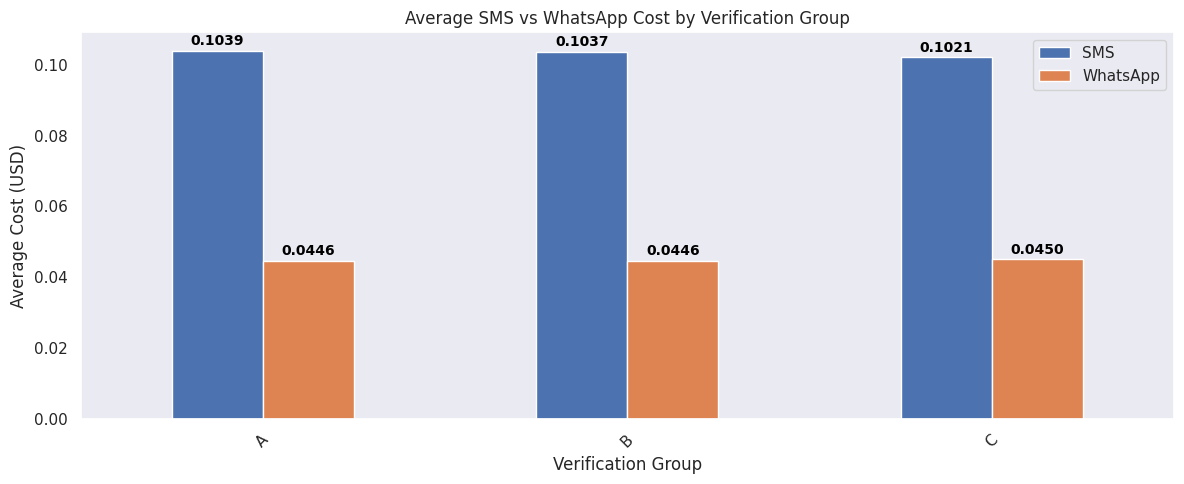

In [18]:

ax = avg_cost_by_group.plot(
    x='group',
    kind='bar',
    figsize=(12,5),
    title='Average SMS vs WhatsApp Cost by Verification Group'
)

plt.xlabel('Verification Group')
plt.ylabel('Average Cost (USD)')
plt.legend(['SMS', 'WhatsApp'])
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()


for container in ax.containers:
    # Add labels to each bar
    ax.bar_label(
        container,
        fmt='%.4f',
        label_type='edge',
        fontsize=10,
        fontweight='bold',
        color='black',
        padding=2
    )

plt.show()


In [19]:
# Cost average
avg_costs = final_df[['sms_usd', 'whatsapp_usd']].mean().reset_index()

# Rename columns
avg_costs.columns = ['Cost_Type', 'Average_USD']

print("Overall average SMS and WhatsApp costs:")
display(avg_costs)


Overall average SMS and WhatsApp costs:


,Cost_Type,Average_USD
0,sms_usd,0.103224
1,whatsapp_usd,0.044741


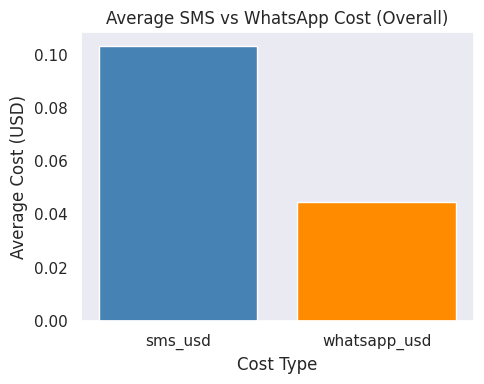

In [20]:

plt.figure(figsize=(5,4))
plt.bar(avg_costs['Cost_Type'], avg_costs['Average_USD'], color=['steelblue', 'darkorange'])
plt.title('Average SMS vs WhatsApp Cost (Overall)')
plt.xlabel('Cost Type')
plt.ylabel('Average Cost (USD)')
plt.grid(False)
plt.tight_layout()
plt.show()


In [23]:
# Count of userID by group (To know each group user traffic)
user_count_by_group = (
    final_df.groupby('group')['userID']
    .count()
    .reset_index(name='User_Count')
)

# Calculate percentage proportion
total_users = user_count_by_group['User_Count'].sum()
user_count_by_group['Percentage'] = ((user_count_by_group['User_Count'] / total_users) * 100).round(2)

# Sort by highest count
user_count_by_group = user_count_by_group.sort_values(by='User_Count', ascending=False)

print("User count and percentage proportion by group (each group user traffic):")
display(user_count_by_group)


User count and percentage proportion by group (each group user traffic):


,group,User_Count,Percentage
0,A,6382,34.64
2,C,6118,33.21
1,B,5924,32.15


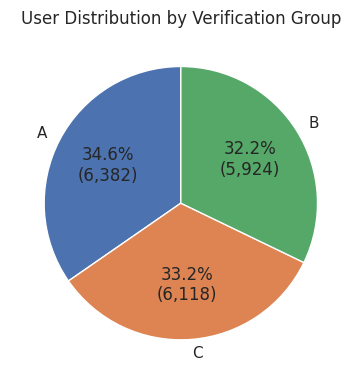

In [24]:
# Display Traffic distribution
plt.figure(figsize=(4,4))

# Custom label formatter showing both count and percentage
def autopct_format(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n({absolute:,})"

values = user_count_by_group['User_Count']
labels = user_count_by_group['group']

plt.pie(
    values,
    labels=labels,
    autopct=lambda pct: autopct_format(pct, values),
    startangle=90,
    pctdistance=0.6
)

plt.title('User Distribution by Verification Group', fontsize=12)
plt.tight_layout()
plt.show()


In [25]:
# How each traffic is distributed along each method

# Count of userID by method
user_count_by_method = (
    final_df.groupby('method')['userID']
    .count()
    .reset_index(name='User_Count')
)

# Calculate percentage proportion
total_users = user_count_by_method['User_Count'].sum()
user_count_by_method['Percentage'] = ((user_count_by_method['User_Count'] / total_users) * 100).round(2)

user_count_by_method = user_count_by_method.sort_values(by='User_Count', ascending=False)

print("User count and percentage proportion by method:")
display(user_count_by_method)


User count and percentage proportion by method:


,method,User_Count,Percentage
0,Sms,13852,75.18
1,Whatsapp,4572,24.82


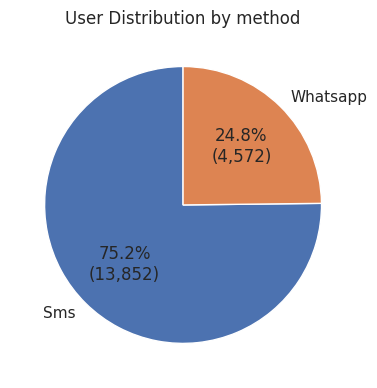

In [26]:
# Display Traffic distribution

plt.figure(figsize=(4,5))

# Custom label formatter showing both count and percentage
def autopct_format(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n({absolute:,})"

values = user_count_by_method['User_Count']
labels = user_count_by_method['method']

plt.pie(
    values,
    labels=labels,
    autopct=lambda pct: autopct_format(pct, values),
    startangle=90,
    pctdistance=0.6  # move percentage text closer to edge
)

plt.title('User Distribution by method', fontsize=12)
plt.tight_layout()
plt.show()


In [27]:
# Analysing each group seperately with focus on verification
#Percentage representation is percentage in parent group

#  Group and summarize
user_summary = (
    final_df.groupby(['group', 'verified', 'method'])['userID']
    .count()
    .reset_index(name='User_Count')
)

# Build combined tables (one per group)
for grp in sorted(user_summary['group'].unique()):
    group_data = user_summary[user_summary['group'] == grp].copy()

    # Calculate total users within group
    total_users = group_data['User_Count'].sum()
    group_data['Percentage'] = (group_data['User_Count'] / total_users * 100).round(2)

    # Pivot so that verified statuses become columns
    pivot_table = (
        group_data
        .pivot(index='method', columns='verified', values=['User_Count', 'Percentage'])
        .fillna(0)
    )

    #  Clean up the column names (make them clearer)
    pivot_table.columns = [
        f"{metric}_{'Verified' if status else 'NotVerified'}"
        for metric, status in pivot_table.columns
    ]

    print(f"\n= Group: {grp} =")
    display(pivot_table.reset_index())




= Group: A =


,method,User_Count_NotVerified,User_Count_Verified,Percentage_NotVerified,Percentage_Verified
0,Sms,809.0,5573.0,12.68,87.32



= Group: B =


,method,User_Count_NotVerified,User_Count_Verified,Percentage_NotVerified,Percentage_Verified
0,Sms,369.0,4888.0,6.23,82.51
1,Whatsapp,57.0,610.0,0.96,10.30



= Group: C =


,method,User_Count_NotVerified,User_Count_Verified,Percentage_NotVerified,Percentage_Verified
0,Sms,103.0,2110.0,1.68,34.49
1,Whatsapp,336.0,3569.0,5.49,58.34


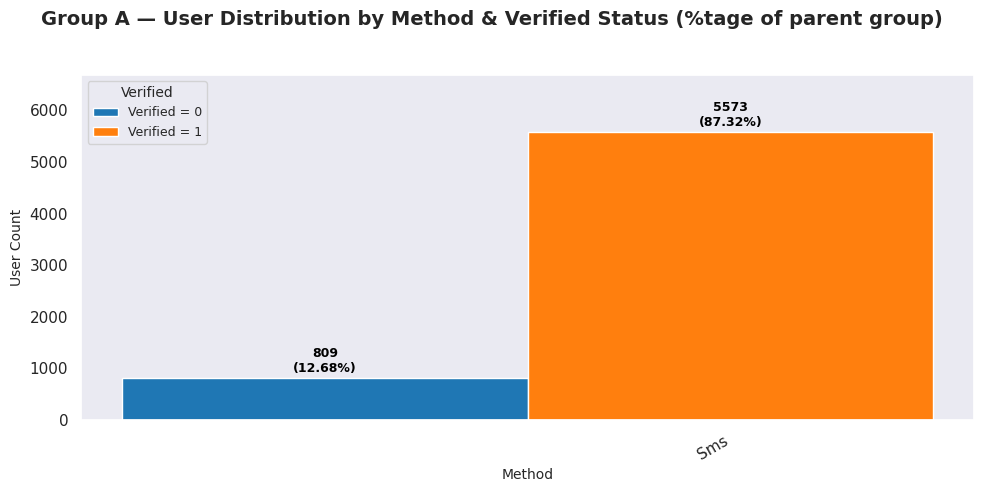

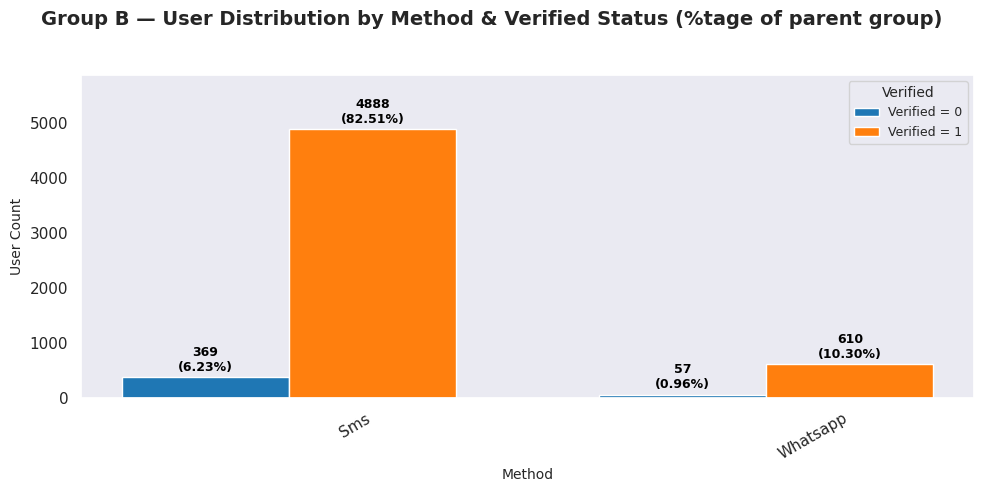

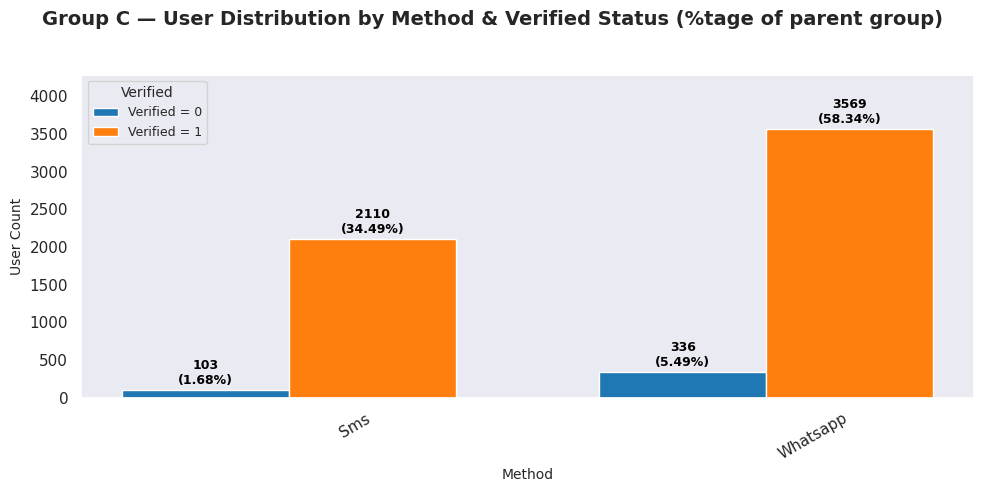

In [28]:

# Ensure verified is numeric (0/1)
user_summary['verified'] = user_summary['verified'].astype(int)

# Define colors for verified statuses
colors = {0: '#1f77b4', 1: '#ff7f0e'}  # blue = Not Verified, orange = Verified

for grp in sorted(user_summary['group'].unique()):
    group_data = user_summary[user_summary['group'] == grp].copy()

    # Compute total users per group for percentage
    total_users = group_data['User_Count'].sum()
    group_data['Percentage'] = (group_data['User_Count'] / total_users * 100).round(2)

    methods = group_data['method'].unique()
    verified_statuses = sorted(group_data['verified'].unique())

    x = np.arange(len(methods))
    width = 0.35  # each bar width
    y_max = group_data['User_Count'].max() * 1.2  # consistent chart height

    # --- Create single clustered chart ---
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle(
        f'Group {grp} — User Distribution by Method & Verified Status (%tage of parent group)',
        fontsize=14, fontweight='bold'
    )

    # Plot bars for each verified status
    for i, status in enumerate(verified_statuses):
        subset = (
            group_data[group_data['verified'] == status]
            .set_index('method')
            .reindex(methods)
            .fillna(0)
        )
        bars = ax.bar(
            x + (i - len(verified_statuses) / 2) * width,
            subset['User_Count'],
            width,
            label=f"Verified = {status}",
            color=colors[status]
        )


        for bar, c, p in zip(bars, subset['User_Count'], subset['Percentage']):
            height = bar.get_height()
            label_text = f"{int(c)}\n({p:.2f}%)"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + y_max * 0.01,
                label_text,
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold',
                color='black'
            )


    ax.set_xlabel('Method', fontsize=10)
    ax.set_ylabel('User Count', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=30, ha='right')
    ax.set_ylim(0, y_max)
    ax.legend(title='Verified', fontsize=9, title_fontsize=10)
    ax.grid(False)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [29]:
# Analysing each group seperately with focus on verification
#Percentage representation is percentage of grand total

#  Group and summarize across all data
user_summary = (
    final_df.groupby(['group', 'method', 'verified'])['userID']
    .count()
    .reset_index(name='User_Count')
)

# Compute percentage of grand total
grand_total = user_summary['User_Count'].sum()
user_summary['Percentage'] = (user_summary['User_Count'] / grand_total * 100).round(2)

#  Pivot verified statuses into columns (single table for all groups)
pivot_table = (
    user_summary
    .pivot_table(
        index=['group', 'method'],
        columns='verified',
        values=['User_Count', 'Percentage']
    )
    .fillna(0)
)

#  Clean column names
pivot_table.columns = [
    f"{metric}_{'Verified' if status else 'NotVerified'}"
    for metric, status in pivot_table.columns
]

# Reset index for a clean table
#pivot_table = pivot_table.reset_index()

display(pivot_table)


Percentage_NotVerified  Percentage_Verified  \
group method                                                  
A     Sms                         4.39                30.25   
B     Sms                         2.00                26.53   
      Whatsapp                    0.31                 3.31   
C     Sms                         0.56                11.45   
      Whatsapp                    1.82                19.37   

                User_Count_NotVerified  User_Count_Verified  
group method                                                 
A     Sms                        809.0               5573.0  
B     Sms                        369.0               4888.0  
      Whatsapp                    57.0                610.0  
C     Sms                        103.0               2110.0  
      Whatsapp                   336.0               3569.0

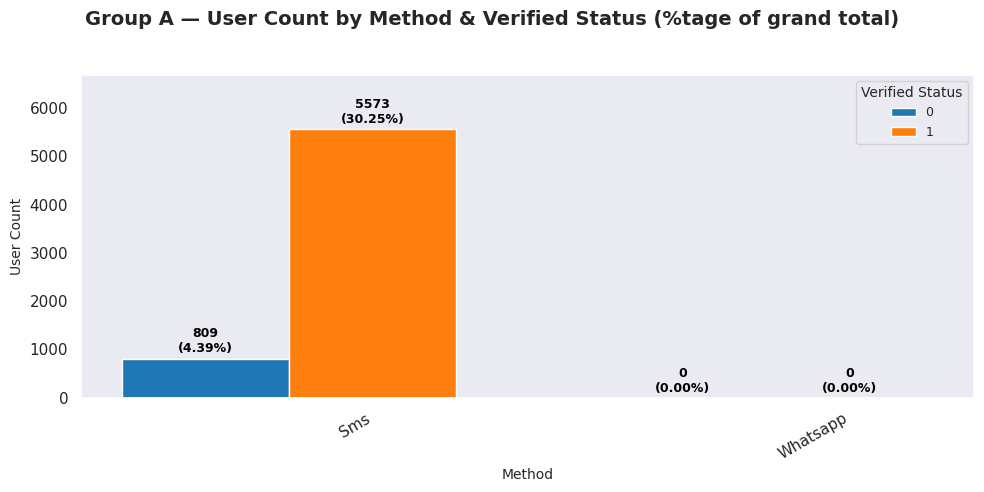

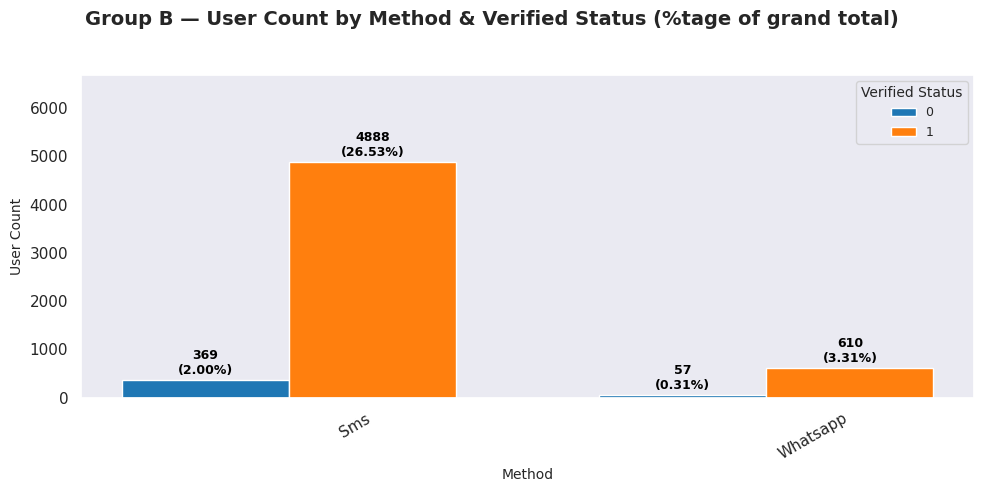

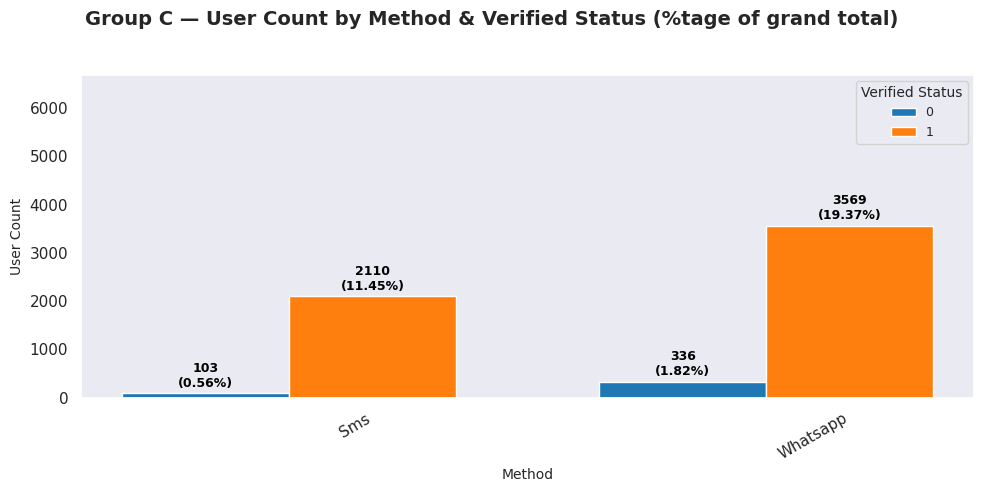

In [30]:

# Ensure verified is numeric (0/1)
user_summary['verified'] = user_summary['verified'].astype(int)

# Get unique groups, methods, verified statuses
groups = sorted(user_summary['group'].unique())
methods = sorted(user_summary['method'].unique())
verified_statuses = sorted(user_summary['verified'].unique())

x = np.arange(len(methods))  # positions for methods
width = 0.35  # bar width
colors = ['#1f77b4', '#ff7f0e']  # blue = 0, orange = 1

# Determine consistent Y-axis max for all groups
y_max = user_summary['User_Count'].max() * 1.2

for grp in groups:
    group_data = user_summary[user_summary['group'] == grp].copy()

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle(f'Group {grp} — User Count by Method & Verified Status (%tage of grand total)', fontsize=14, fontweight='bold')

    # Plot bars for each verified status
    for i, status in enumerate(verified_statuses):
        subset = group_data[group_data['verified'] == status].set_index('method').reindex(methods).fillna(0)
        bars = ax.bar(
            x + (i - len(verified_statuses)/2) * width,
            subset['User_Count'],
            width,
            label=f"{status}",
            color=colors[i]
        )

        for bar, c, p in zip(bars, subset['User_Count'], subset['Percentage']):
            height = bar.get_height()
            label_text = f"{int(c)}\n({p:.2f}%)"

            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + y_max*0.01,  # small offset above bar
                label_text,
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold',
                color='black'
            )


    ax.set_xlabel('Method', fontsize=10)
    ax.set_ylabel('User Count', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=30, ha='right')
    ax.set_ylim(0, y_max)
    ax.legend(title='Verified Status', fontsize=9, title_fontsize=10)
    ax.grid(False)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()




In [31]:
# Analysing the groups together with focus on verification
#Percentage representation is percentage in parent group

# Group and summarize across all data
user_summary = (
    final_df.groupby(['group', 'method', 'verified'])['userID']
    .count()
    .reset_index(name='User_Count')
)

# Compute percentage per parent row (group + method)
user_summary['Total_Per_Method'] = user_summary.groupby(['group', 'method'])['User_Count'].transform('sum')
user_summary['Percentage'] = (user_summary['User_Count'] / user_summary['Total_Per_Method'] * 100).round(2)

#  Pivot verified statuses into columns (single table for all groups)
pivot_table = (
    user_summary
    .pivot_table(
        index=['group', 'method'],
        columns='verified',
        values=['User_Count', 'Percentage']
    )
    .fillna(0)
)

# Clean column names
pivot_table.columns = [
    f"{metric}_{'Verified' if status else 'NotVerified'}"
    for metric, status in pivot_table.columns
]


#pivot_table = pivot_table.reset_index()


display(pivot_table)


Percentage_NotVerified  Percentage_Verified  \
group method                                                  
A     Sms                        12.68                87.32   
B     Sms                         7.02                92.98   
      Whatsapp                    8.55                91.45   
C     Sms                         4.65                95.35   
      Whatsapp                    8.60                91.40   

                User_Count_NotVerified  User_Count_Verified  
group method                                                 
A     Sms                        809.0               5573.0  
B     Sms                        369.0               4888.0  
      Whatsapp                    57.0                610.0  
C     Sms                        103.0               2110.0  
      Whatsapp                   336.0               3569.0

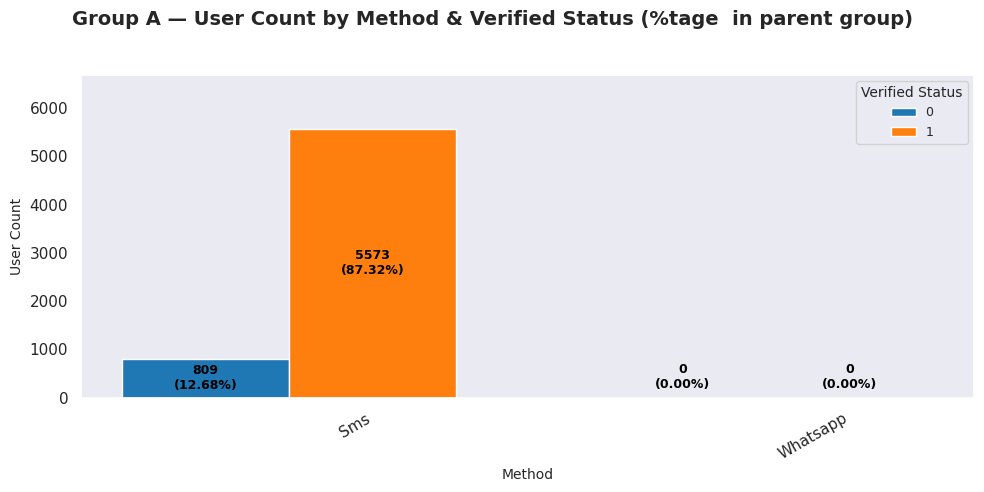

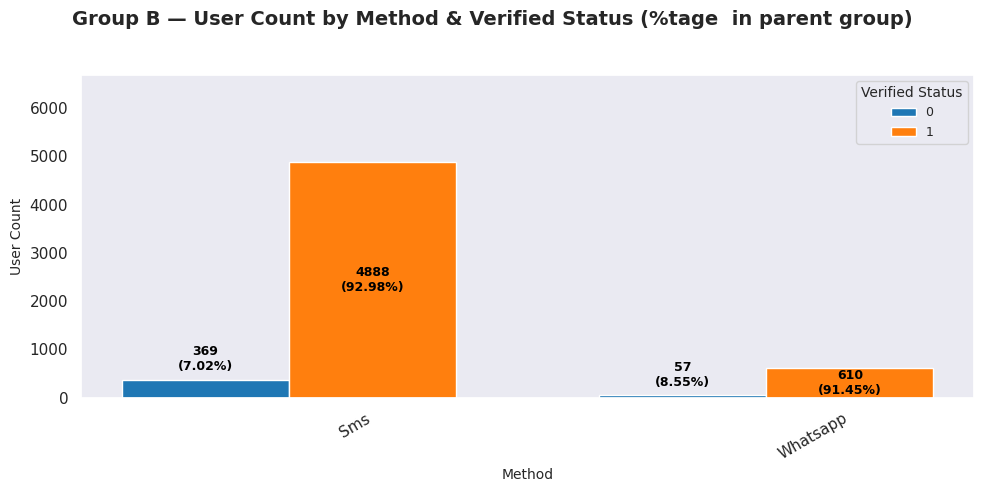

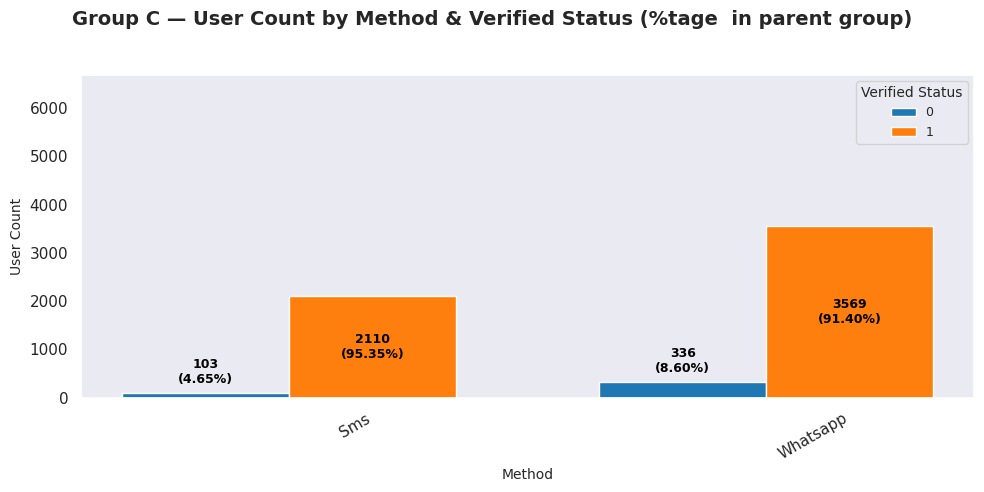

In [32]:

# Ensure verified is numeric (0/1)
user_summary['verified'] = user_summary['verified'].astype(int)

# Unique groups, methods, verified statuses
groups = sorted(user_summary['group'].unique())
methods = sorted(user_summary['method'].unique())
verified_statuses = sorted(user_summary['verified'].unique())

x = np.arange(len(methods))  # positions for methods
width = 0.35  # width of each bar
colors = ['#1f77b4', '#ff7f0e']  # blue = 0, orange = 1

# Determine consistent Y-axis max for all groups
y_max = user_summary['User_Count'].max() * 1.2

for grp in groups:
    group_data = user_summary[user_summary['group'] == grp].copy()

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle(f'Group {grp} — User Count by Method & Verified Status (%tage  in parent group)', fontsize=14, fontweight='bold')

    # Plot bars for each verified status
    for i, status in enumerate(verified_statuses):
        subset = group_data[group_data['verified'] == status].set_index('method').reindex(methods).fillna(0)
        bars = ax.bar(
            x + (i - len(verified_statuses)/2) * width,
            subset['User_Count'],
            width,
            label=f"{status}",
            color=colors[i]
        )
        # Add bold black data labels
        for bar, pct in zip(bars, subset['Percentage']):
            height = bar.get_height()
            label_text = f"{int(height)}\n({pct:.2f}%)"

            if height < y_max*0.07:  # short bars → label above
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    height + y_max*0.02,
                    label_text,
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    fontweight='bold',
                    color='black'
                )
            else:  # taller bars → label inside
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    height/2,
                    label_text,
                    ha='center',
                    va='center',
                    fontsize=9,
                    fontweight='bold',
                    color='black'
                )


    ax.set_xlabel('Method', fontsize=10)
    ax.set_ylabel('User Count', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=30, ha='right')
    ax.set_ylim(0, y_max)
    ax.legend(title='Verified Status', fontsize=9, title_fontsize=10)
    ax.grid(False)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


**Pivot Table for Verification Conversion Rate**

In [36]:

final_df['verified'] = final_df['verified'].astype(int)

# --- Create pivot table ---
pivot_table = (
    final_df
    .groupby('group')
    .agg(
        User_Count=('userID', 'count'),
        Verified_Count=('verified', 'sum')
    )
    .reset_index()
)

# Calculate conversion rate (%)
pivot_table['Verified_Conversion_Rate (%)'] = (
    pivot_table['Verified_Count'] / pivot_table['User_Count'] * 100
).round(2)

display(pivot_table)



,group,User_Count,Verified_Count,Verified_Conversion_Rate (%)
0,A,6382,5573,87.32
1,B,5924,5498,92.81
2,C,6118,5679,92.82


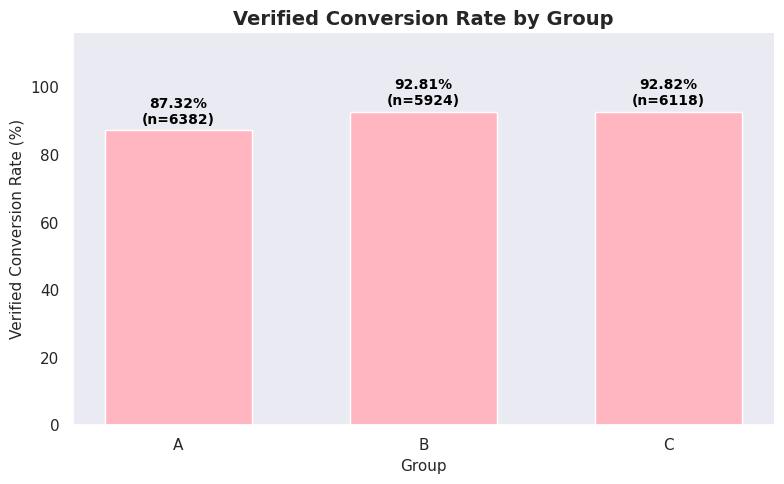

In [39]:

# --- Prepare pivot table ---
final_df['verified'] = final_df['verified'].astype(int)
pivot_table = (
    final_df
    .groupby('group')
    .agg(
        User_Count=('userID', 'count'),
        Verified_Count=('verified', 'sum')
    )
    .reset_index()
)
pivot_table['Verified_Conversion_Rate (%)'] = (
    pivot_table['Verified_Count'] / pivot_table['User_Count'] * 100
).round(2)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    pivot_table['group'],
    pivot_table['Verified_Conversion_Rate (%)'],
    color='#ffb6c1',  # light pink
    width=0.6
)

# --- Add data labels (Conversion Rate + User Count) ---
for bar, rate, count in zip(bars, pivot_table['Verified_Conversion_Rate (%)'], pivot_table['User_Count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.2f}%\n(n={count})",  # two-line label
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

# --- Formatting ---
ax.set_title('Verified Conversion Rate by Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Group', fontsize=11)
ax.set_ylabel('Verified Conversion Rate (%)', fontsize=11)
ax.set_ylim(0, pivot_table['Verified_Conversion_Rate (%)'].max() * 1.25)
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
